# Censo de Datos
## ¿Cuántos datos hay en cada sección del análisis y dónde faltan?

Objetivo: numerar los datos disponibles en cada sección del estudio (temporada del
año × periodo escolar × zona de monitoreo × contaminante) y verificar que ni los
huecos ni la imputación estén sesgando las comparaciones que el análisis hace.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Diagnostic: data census and balance checks (coverage, imputed cells, days per season and regime). / Diagnóstico: censo de datos y balance (cobertura, celdas imputadas, días por temporada y régimen). The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

output_dir = Path('../data_processed')
censo_dir = output_dir / 'censo_datos'
censo_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'base_horaria_estaciones_fisicas.csv.gz',
                       output_dir / 'base_horaria_zonas.csv.gz',
                       output_dir / 'datos_horarios_imputados_hibrido.csv.gz',
                       output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'calendario_oficial_sep.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 5 archivos


## 2. Carga de datos (toda la cadena es propia, notebook 00)

In [2]:
# Base horaria observada por zona (con sus huecos) y por estación física
base = pd.read_csv('../data_processed/base_horaria_zonas.csv.gz', parse_dates=['date'])
base_fisicas = pd.read_csv('../data_processed/base_horaria_estaciones_fisicas.csv.gz', parse_dates=['date'])

# Serie horaria imputada (vía híbrida, con bandera de qué se imputó)
imputado = pd.read_csv('../data_processed/datos_horarios_imputados_hibrido.csv.gz', parse_dates=['date'])

# Panel final de análisis y calendario oficial (notebooks 00 y 01)
panel = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
calendario = pd.read_csv('../data_processed/calendario_oficial_sep.csv', parse_dates=['date'])

print("=" * 70)
print("DATOS CARGADOS")
print("=" * 70)
print(f"Base horaria por zona (observada): {base.shape[0]:,} filas")
print(f"Base horaria por estación física:  {base_fisicas.shape[0]:,} filas")
print(f"Serie horaria imputada (híbrida):  {imputado.shape[0]:,} filas")
print(f"Panel final de análisis: {panel.shape[0]:,} filas día-zona")

DATOS CARGADOS
Base horaria por zona (observada): 772,426 filas
Base horaria por estación física:  1,751,750 filas
Serie horaria imputada (híbrida):  789,120 filas
Panel final de análisis: 6,576 filas día-zona


## 3. Robustez de la consolidación por zona (media vs mediana entre estaciones)

Cada valor horario de zona es el promedio de sus estaciones físicas. ¿Qué tanto
cambiaría la celda de análisis si en lugar de la media se usara la mediana entre
estaciones? Si el cambio es chico comparado con los efectos que se contrastan,
la elección es inocua.

In [3]:
base_fisicas['fecha'] = base_fisicas['date'].dt.normalize()
celda_media = (base_fisicas.groupby(['zona', 'fecha', 'parametro'])['valor'].mean())
celda_mediana = (base_fisicas.groupby(['zona', 'fecha', 'parametro'])['valor'].median())
comparacion = pd.concat([celda_media.rename('media'), celda_mediana.rename('mediana')], axis=1).dropna()

print("=" * 70)
print("ROBUSTEZ DE LA CELDA DÍA-ZONA A LA CONSOLIDACIÓN (media vs mediana entre estaciones)")
print("=" * 70)
filas_robustez = []
for parametro, sub in comparacion.groupby(level=2):
    correlacion = sub['media'].corr(sub['mediana'])
    dif_relativa = (abs(sub['media'] - sub['mediana']) / sub['mediana'].replace(0, np.nan)).median() * 100
    filas_robustez.append({'parametro': parametro, 'corr_media_mediana': round(correlacion, 4),
                           'dif_relativa_mediana_pct': round(dif_relativa, 1)})
    print(f"  {parametro}: corr = {correlacion:.4f} | diferencia relativa mediana = {dif_relativa:.1f}%")
corrs = [f['corr_media_mediana'] for f in filas_robustez]
print(f"\n=> Correlaciones de {min(corrs):.2f} a {max(corrs):.2f}: ambas consolidaciones cuentan la misma historia.")
print("   Además el diseño principal (el gap DENTRO del día) es poco sensible a la elección:")
print("   una diferencia de NIVEL entre media y mediana pega igual a las dos franjas")
print("   del mismo día y se cancela en la resta.")
pd.DataFrame(filas_robustez).to_csv(censo_dir / 'robustez_consolidacion_media_vs_mediana.csv', index=False)
print(f"Guardado en: {censo_dir / 'robustez_consolidacion_media_vs_mediana.csv'}")

ROBUSTEZ DE LA CELDA DÍA-ZONA A LA CONSOLIDACIÓN (media vs mediana entre estaciones)
  CO: corr = 0.9621 | diferencia relativa mediana = 5.5%
  NO2: corr = 0.9747 | diferencia relativa mediana = 8.7%
  O3: corr = 0.8804 | diferencia relativa mediana = 12.9%
  PM10: corr = 0.9678 | diferencia relativa mediana = 7.1%
  PM2.5: corr = 0.9416 | diferencia relativa mediana = 8.7%

=> Correlaciones de 0.88 a 0.97: ambas consolidaciones cuentan la misma historia.
   Además el diseño principal (el gap DENTRO del día) es poco sensible a la elección:
   una diferencia de NIVEL entre media y mediana pega igual a las dos franjas
   del mismo día y se cancela en la resta.
Guardado en: ../data_processed/censo_datos/robustez_consolidacion_media_vs_mediana.csv


## 4. Cobertura horaria observada por zona y contaminante

Contra la malla completa esperada (todas las horas del periodo × zona × contaminante).
Las horas ausentes son los huecos que la imputación rellena; por construcción, la
imputación NUNCA modifica una hora observada (solo rellena las ausentes).

In [4]:
fecha_min, fecha_max = base['date'].min(), base['date'].max()
malla_horas = pd.date_range(fecha_min, fecha_max, freq='h')
horas_esperadas = len(malla_horas)

validos = base.dropna(subset=['valor']).groupby(['estacion', 'parametro'])['valor'].count()
tabla_cobertura = validos.unstack('parametro').reindex(columns=contaminantes)
tabla_faltante_pct = ((1 - tabla_cobertura / horas_esperadas) * 100).round(1)

print("=" * 70)
print(f"COBERTURA OBSERVADA ({fecha_min.date()} a {fecha_max.date()}: {horas_esperadas:,} horas esperadas por celda)")
print("=" * 70)
print("\nHoras válidas por zona y contaminante:")
print(tabla_cobertura)
print("\n% de horas faltantes (huecos que la imputación rellena):")
print(tabla_faltante_pct)

tabla_cobertura.to_csv(censo_dir / 'horas_validas_por_estacion_contaminante.csv')
tabla_faltante_pct.to_csv(censo_dir / 'pct_faltante_por_estacion_contaminante.csv')
print(f"\nGuardado en: {censo_dir / 'horas_validas_por_estacion_contaminante.csv'}")
print(f"Guardado en: {censo_dir / 'pct_faltante_por_estacion_contaminante.csv'}")

COBERTURA OBSERVADA (2023-01-01 a 2025-12-31: 26,304 horas esperadas por celda)

Horas válidas por zona y contaminante:
parametro     CO    NO2     O3   PM10  PM2.5
estacion                                    
CENTRO     24184  25498  25270  25690  22365
NORESTE3   25999  25526  26245  26272  25538
NOROESTE3  26254  26037  26112  26267  22563
NORTE2     26252  26257  26112  26233  26017
SUR        26275  26276  26274  26276  26275
SUROESTE2  26219  26271  26150  26243  25476

% de horas faltantes (huecos que la imputación rellena):
parametro   CO  NO2   O3  PM10  PM2.5
estacion                             
CENTRO     8.1  3.1  3.9   2.3   15.0
NORESTE3   1.2  3.0  0.2   0.1    2.9
NOROESTE3  0.2  1.0  0.7   0.1   14.2
NORTE2     0.2  0.2  0.7   0.3    1.1
SUR        0.1  0.1  0.1   0.1    0.1
SUROESTE2  0.3  0.1  0.6   0.2    3.1

Guardado en: ../data_processed/censo_datos/horas_validas_por_estacion_contaminante.csv
Guardado en: ../data_processed/censo_datos/pct_faltante_por_estacion_c

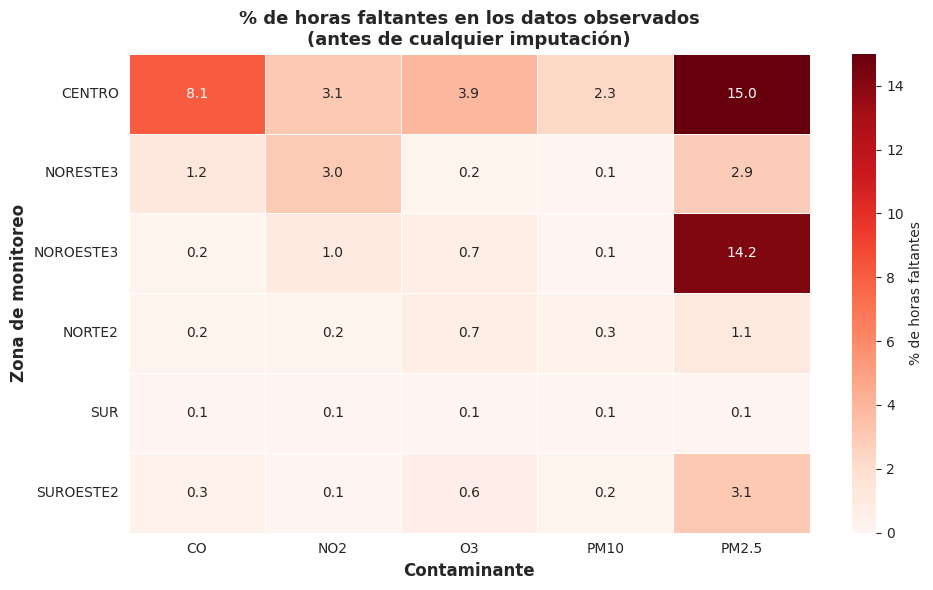

Guardado gráfico en: ../data_processed/censo_datos/01_pct_faltante_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(tabla_faltante_pct, annot=True, fmt='.1f', cmap='Reds', vmin=0,
            cbar_kws={'label': '% de horas faltantes'}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Zona de monitoreo', fontsize=12, fontweight='bold')
ax.set_title('% de horas faltantes en los datos observados\n(antes de cualquier imputación)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(censo_dir / '01_pct_faltante_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {censo_dir / '01_pct_faltante_heatmap.png'}")

## 5. ¿Los huecos se concentran en algún mes? (zona × mes)

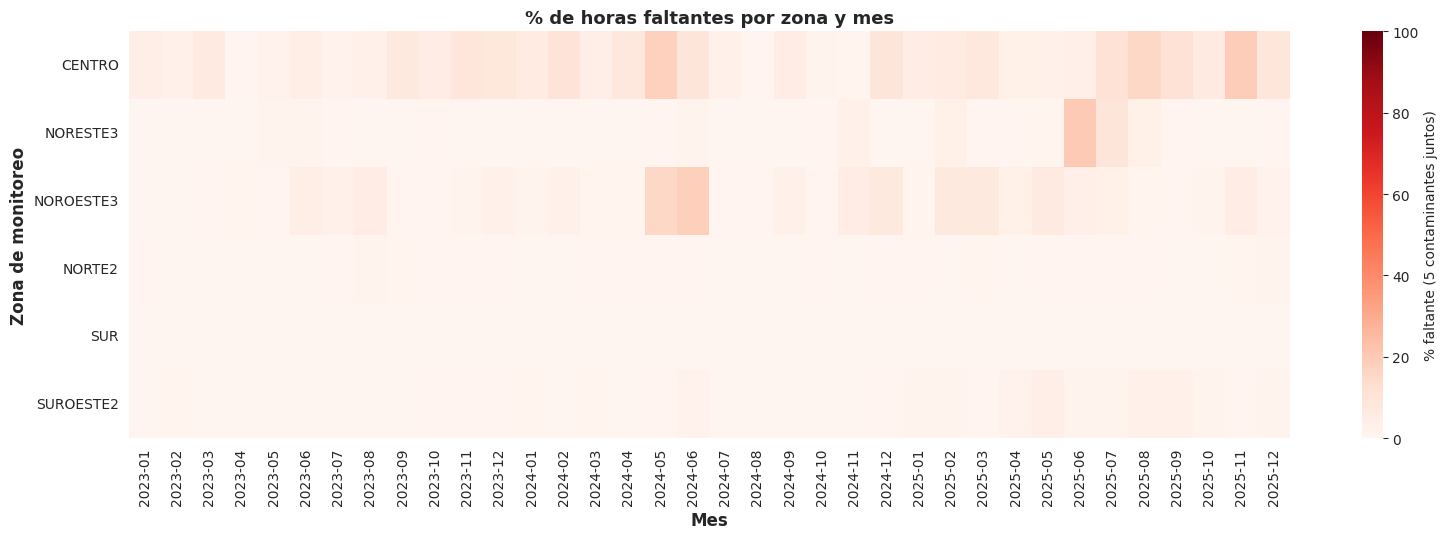

Guardado en: ../data_processed/censo_datos/pct_faltante_por_estacion_mes.csv
Guardado gráfico en: ../data_processed/censo_datos/02_pct_faltante_por_mes_heatmap.png


In [6]:
base_mes = base.copy()
base_mes['anio_mes'] = base_mes['date'].dt.to_period('M').astype(str)
malla_mes = pd.Series(malla_horas).dt.to_period('M').astype(str).value_counts().sort_index()

validos_mes = (base_mes.dropna(subset=['valor'])
               .groupby(['estacion', 'anio_mes'])['valor'].count()
               .unstack('anio_mes'))
esperadas_mes = malla_mes * len(contaminantes)
pct_faltante_mes = (1 - validos_mes.div(esperadas_mes, axis=1)) * 100

fig, ax = plt.subplots(figsize=(16, 5.5))
sns.heatmap(pct_faltante_mes, cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '% faltante (5 contaminantes juntos)'}, ax=ax)
ax.set_xlabel('Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Zona de monitoreo', fontsize=12, fontweight='bold')
ax.set_title('% de horas faltantes por zona y mes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(censo_dir / '02_pct_faltante_por_mes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

pct_faltante_mes.round(1).to_csv(censo_dir / 'pct_faltante_por_estacion_mes.csv')
print(f"Guardado en: {censo_dir / 'pct_faltante_por_estacion_mes.csv'}")
print(f"Guardado gráfico en: {censo_dir / '02_pct_faltante_por_mes_heatmap.png'}")

## 6. Censo de la franja pico: horas válidas por celda y % imputado

Cada celda día-zona-contaminante de la franja pico se construye con 2 horas (los
sellos 07 y 08). Contra la malla completa esperada, se cuenta cuántas celdas tenían
2, 1 o 0 horas válidas observadas (0 horas = la celda completa salió de la imputación).

In [7]:
base['fecha'] = base['date'].dt.normalize()
base['hora'] = base['date'].dt.hour
pico_obs = base[base['hora'].isin([7, 8])].dropna(subset=['valor'])

horas_unicas = (pico_obs.groupby(['fecha', 'estacion', 'parametro'])['hora'].nunique()
                .rename('horas_validas'))

fechas_todas = pd.date_range(base['fecha'].min(), base['fecha'].max(), freq='D')
zonas_todas = sorted(base['estacion'].unique())
malla_completa = pd.MultiIndex.from_product([fechas_todas, zonas_todas, contaminantes],
                                            names=['fecha', 'estacion', 'parametro'])
censo_celdas = horas_unicas.reindex(malla_completa).fillna(0).astype(int).rename('horas_validas').to_frame()

distribucion = censo_celdas['horas_validas'].value_counts().sort_index()
print("=" * 70)
print("HORAS VÁLIDAS POR CELDA DÍA-ZONA-CONTAMINANTE (franja pico, de 2 posibles)")
print("=" * 70)
for horas, n in distribucion.items():
    print(f"  {horas} horas válidas: {n:,} celdas ({n/len(censo_celdas)*100:.1f}%)")

HORAS VÁLIDAS POR CELDA DÍA-ZONA-CONTAMINANTE (franja pico, de 2 posibles)
  0 horas válidas: 595 celdas (1.8%)
  1 horas válidas: 273 celdas (0.8%)
  2 horas válidas: 32,012 celdas (97.4%)


In [8]:
# ¿El % de celdas imputadas por completo se distribuye igual entre regímenes y temporadas?
censo_celdas = censo_celdas.reset_index()
mapa_clase = calendario.set_index('date')['lectivo']
censo_celdas['clase'] = censo_celdas['fecha'].map(mapa_clase)
mapa_temporada4 = {12: 'invierno', 1: 'invierno', 2: 'invierno',
                   3: 'primavera', 4: 'primavera', 5: 'primavera',
                   6: 'verano', 7: 'verano', 8: 'verano',
                   9: 'otono', 10: 'otono', 11: 'otono'}
censo_celdas['temporada4'] = censo_celdas['fecha'].dt.month.map(mapa_temporada4)
censo_celdas['celda_imputada'] = (censo_celdas['horas_validas'] == 0).astype(int)

balance_imputacion = (censo_celdas.groupby(['temporada4', 'clase'])
                      .agg(celdas=('celda_imputada', 'count'),
                           pct_imputada=('celda_imputada', lambda s: round(s.mean() * 100, 2)))
                      .reset_index())
orden_temporadas = ['invierno', 'primavera', 'verano', 'otono']
balance_imputacion['temporada4'] = pd.Categorical(balance_imputacion['temporada4'], orden_temporadas)
balance_imputacion = balance_imputacion.sort_values(['temporada4', 'clase'])

print("\n% DE CELDAS TOTALMENTE IMPUTADAS POR TEMPORADA Y RÉGIMEN:")
print(balance_imputacion.to_string(index=False))
balance_imputacion.to_csv(censo_dir / 'balance_imputacion_temporada_regimen.csv', index=False)
print(f"\nGuardado en: {censo_dir / 'balance_imputacion_temporada_regimen.csv'}")


% DE CELDAS TOTALMENTE IMPUTADAS POR TEMPORADA Y RÉGIMEN:
temporada4  clase  celdas  pct_imputada
  invierno      0    1740          0.92
  invierno      1    6390          2.28
 primavera      0    1080          0.28
 primavera      1    7200          1.85
    verano      0    3540          1.07
    verano      1    4740          2.89
     otono      1    8190          1.49

Guardado en: ../data_processed/censo_datos/balance_imputacion_temporada_regimen.csv


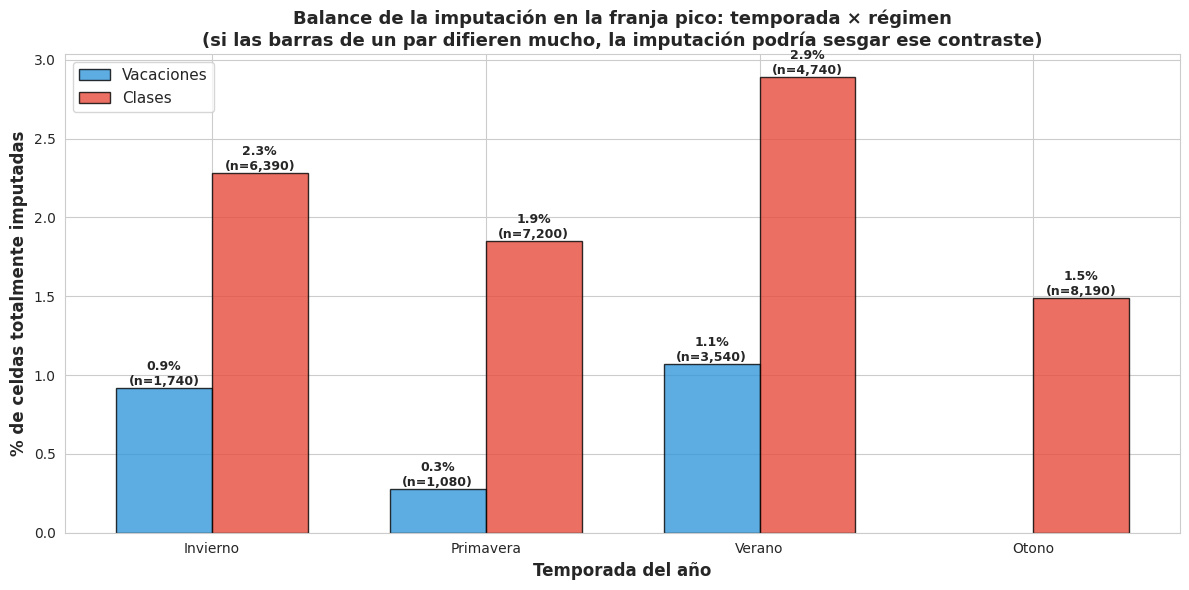

Guardado gráfico en: ../data_processed/censo_datos/03_balance_imputacion_temporada_regimen.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(orden_temporadas))
width = 0.35
vac = balance_imputacion[balance_imputacion['clase'] == 0].set_index('temporada4').reindex(orden_temporadas)
cla = balance_imputacion[balance_imputacion['clase'] == 1].set_index('temporada4').reindex(orden_temporadas)

bars1 = ax.bar(x - width/2, vac['pct_imputada'], width,
               label='Vacaciones', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, cla['pct_imputada'], width,
               label='Clases', color='#e74c3c', alpha=0.8, edgecolor='black')

for bars, datos in [(bars1, vac), (bars2, cla)]:
    for bar, (_, fila) in zip(bars, datos.iterrows()):
        if np.isnan(bar.get_height()):
            continue
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f"{bar.get_height():.1f}%\n(n={int(fila['celdas']):,})",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in orden_temporadas])
ax.set_xlabel('Temporada del año', fontsize=12, fontweight='bold')
ax.set_ylabel('% de celdas totalmente imputadas', fontsize=12, fontweight='bold')
ax.set_title('Balance de la imputación en la franja pico: temporada × régimen\n(si las barras de un par difieren mucho, la imputación podría sesgar ese contraste)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(censo_dir / '03_balance_imputacion_temporada_regimen.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {censo_dir / '03_balance_imputacion_temporada_regimen.png'}")

## 7. Días de análisis por temporada, régimen y zona de monitoreo

In [10]:
panel['temporada4'] = panel['mes'].map(mapa_temporada4)

conteo_temporada_regimen = (panel.groupby(['temporada4', 'clase'])['date']
                            .nunique().rename('n_dias').reset_index())
conteo_temporada_regimen['temporada4'] = pd.Categorical(conteo_temporada_regimen['temporada4'], orden_temporadas)
conteo_temporada_regimen = conteo_temporada_regimen.sort_values(['temporada4', 'clase'])

print("=" * 70)
print("DÍAS DE ANÁLISIS POR TEMPORADA Y RÉGIMEN (panel final, franja pico)")
print("=" * 70)
print(conteo_temporada_regimen.to_string(index=False))

conteo_mes_anio = (panel.groupby(['anio', 'mes', 'clase'])['date']
                   .nunique().rename('n_dias').reset_index())
conteo_estacion = panel.groupby('estacion')['date'].nunique().rename('n_dias')

print("\nDías por zona de monitoreo en el panel final:")
print(conteo_estacion)

conteo_temporada_regimen.to_csv(censo_dir / 'n_dias_por_temporada_regimen.csv', index=False)

# Variable categórica de 4 niveles: hábil/finde × lectivo/vacaciones
mapa_tipo_dia = calendario.set_index('date')['tipo_dia']
panel['tipo_dia'] = panel['date'].map(mapa_tipo_dia)
conteo_tipo_dia = (panel.groupby('tipo_dia')['date'].nunique()
                   .reindex(['habil_lectivo', 'habil_vacaciones', 'finde_lectivo', 'finde_vacaciones'])
                   .rename('n_dias'))
print("\nDías por tipo de día (hábil/finde × lectivo/vacaciones):")
print(conteo_tipo_dia.to_string())
conteo_tipo_dia.to_csv(censo_dir / 'n_dias_por_tipo_dia.csv')

# Tabla temporada × régimen × hábil/finde (la Tabla 1 del artículo sale de aquí)
panel['habil'] = np.where(panel['tipo_dia'].str.startswith('habil'), 'habil', 'finde')
tabla_temporada_tipo = (panel.groupby(['temporada4', 'clase', 'habil'])['date'].nunique()
                        .rename('n_dias').reset_index())
tabla_temporada_tipo['temporada4'] = pd.Categorical(tabla_temporada_tipo['temporada4'], orden_temporadas)
tabla_temporada_tipo = tabla_temporada_tipo.sort_values(['temporada4', 'clase', 'habil'])
tabla_ancha = (tabla_temporada_tipo.pivot_table(index='temporada4', columns=['clase', 'habil'],
                                                values='n_dias', fill_value=0, observed=False)
               .reindex(orden_temporadas))
tabla_ancha.columns = [f"{'clases' if c == 1 else 'vacaciones'}_{h}" for c, h in tabla_ancha.columns]
tabla_ancha = tabla_ancha.reindex(columns=['vacaciones_habil', 'vacaciones_finde',
                                           'clases_habil', 'clases_finde'], fill_value=0).astype(int)
tabla_ancha.loc['total'] = tabla_ancha.sum()
print("\nDías por temporada, régimen y hábil/fin de semana:")
print(tabla_ancha.to_string())
tabla_ancha.to_csv(censo_dir / 'n_dias_por_temporada_regimen_habil.csv')
conteo_mes_anio.to_csv(censo_dir / 'n_dias_por_mes_anio_regimen.csv', index=False)
conteo_estacion.to_csv(censo_dir / 'n_dias_por_estacion.csv')
print(f"\nGuardado en: {censo_dir / 'n_dias_por_temporada_regimen.csv'}")
print(f"Guardado en: {censo_dir / 'n_dias_por_mes_anio_regimen.csv'}")
print(f"Guardado en: {censo_dir / 'n_dias_por_estacion.csv'}")

DÍAS DE ANÁLISIS POR TEMPORADA Y RÉGIMEN (panel final, franja pico)
temporada4  clase  n_dias
  invierno      0      58
  invierno      1     213
 primavera      0      36
 primavera      1     240
    verano      0     118
    verano      1     158
     otono      1     273

Días por zona de monitoreo en el panel final:
estacion
CENTRO       1096
NORESTE3     1096
NOROESTE3    1096
NORTE2       1096
SUR          1096
SUROESTE2    1096
Name: n_dias, dtype: int64

Días por tipo de día (hábil/finde × lectivo/vacaciones):
tipo_dia
habil_lectivo       628
habil_vacaciones    155
finde_lectivo       256
finde_vacaciones     57

Días por temporada, régimen y hábil/fin de semana:
            vacaciones_habil  vacaciones_finde  clases_habil  clases_finde
temporada4                                                                
invierno                  43                15           152            61
primavera                 30                 6           167            73
verano            

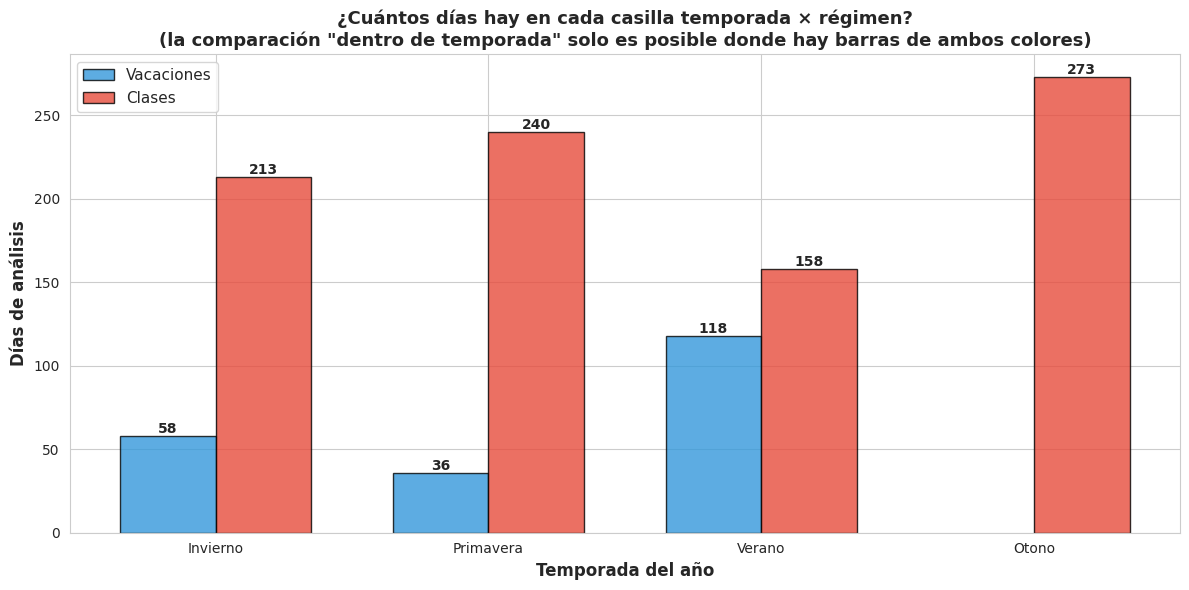

Guardado gráfico en: ../data_processed/censo_datos/04_n_dias_temporada_regimen.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

vac_n = conteo_temporada_regimen[conteo_temporada_regimen['clase'] == 0].set_index('temporada4').reindex(orden_temporadas)
cla_n = conteo_temporada_regimen[conteo_temporada_regimen['clase'] == 1].set_index('temporada4').reindex(orden_temporadas)

bars1 = ax.bar(x - width/2, vac_n['n_dias'], width,
               label='Vacaciones', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, cla_n['n_dias'], width,
               label='Clases', color='#e74c3c', alpha=0.8, edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        if np.isnan(bar.get_height()):
            continue
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{int(bar.get_height())}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in orden_temporadas])
ax.set_xlabel('Temporada del año', fontsize=12, fontweight='bold')
ax.set_ylabel('Días de análisis', fontsize=12, fontweight='bold')
ax.set_title('¿Cuántos días hay en cada casilla temporada × régimen?\n(la comparación "dentro de temporada" solo es posible donde hay barras de ambos colores)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(censo_dir / '04_n_dias_temporada_regimen.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {censo_dir / '04_n_dias_temporada_regimen.png'}")

## 8. Conclusiones del censo

In [12]:
pct_imputadas_global = censo_celdas['celda_imputada'].mean() * 100
diferencia_max = (balance_imputacion.pivot(index='temporada4', columns='clase', values='pct_imputada')
                  .diff(axis=1).iloc[:, -1].abs().max())

print("=" * 70)
print("CONCLUSIONES DEL CENSO DE DATOS")
print("=" * 70)
print(f"1. Celdas de la franja pico totalmente imputadas: {pct_imputadas_global:.1f}% del total")
print(f"   (y {(censo_celdas['horas_validas'] == 1).mean()*100:.1f}% adicional con solo 1 de 2 horas).")
print(f"2. La diferencia máxima de % imputado entre clases y vacaciones dentro de una misma")
print(f"   temporada es de {diferencia_max:.1f} puntos porcentuales.")
print(f"3. El panel final está balanceado entre zonas de monitoreo (mismos días).")
print(f"4. Las casillas temporada × régimen con soporte para comparar dentro de temporada:")
soporte = conteo_temporada_regimen.pivot(index='temporada4', columns='clase', values='n_dias')
for temporada in orden_temporadas:
    fila = soporte.loc[temporada]
    n_vac = 0 if pd.isna(fila.get(0, 0)) else int(fila.get(0, 0))
    n_cla = 0 if pd.isna(fila.get(1, 0)) else int(fila.get(1, 0))
    print(f"   - {temporada:10s}: vacaciones={n_vac:3d} días, clases={n_cla:3d} días")
print(f"5. Recordatorio: todas las conclusiones del análisis se verifican con DOS imputaciones")
print(f"   independientes (híbrida y MIMA) con resultados coincidentes.")

print('\nFINALIZADO')

CONCLUSIONES DEL CENSO DE DATOS
1. Celdas de la franja pico totalmente imputadas: 1.8% del total
   (y 0.8% adicional con solo 1 de 2 horas).
2. La diferencia máxima de % imputado entre clases y vacaciones dentro de una misma
   temporada es de 1.8 puntos porcentuales.
3. El panel final está balanceado entre zonas de monitoreo (mismos días).
4. Las casillas temporada × régimen con soporte para comparar dentro de temporada:
   - invierno  : vacaciones= 58 días, clases=213 días
   - primavera : vacaciones= 36 días, clases=240 días
   - verano    : vacaciones=118 días, clases=158 días
   - otono     : vacaciones=  0 días, clases=273 días
5. Recordatorio: todas las conclusiones del análisis se verifican con DOS imputaciones
   independientes (híbrida y MIMA) con resultados coincidentes.

FINALIZADO
